In [4]:
import site
import sys

user_site = site.getusersitepackages()
if user_site in sys.path:
    sys.path.remove(user_site)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import scipy.stats as stats
from scipy.stats import ttest_ind
from itertools import combinations
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split, KFold, cross_validate, cross_val_predict
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance


In [5]:
data = pd.read_excel(r"C:\Users\aakas\OneDrive\Documents\Scaler\Insurance Cost Prediction DS Portfolio Project\insurance.xlsx")

In [6]:
print("Columns in the dataset: ", data.columns)

Columns in the dataset:  Index(['Age', 'Diabetes', 'BloodPressureProblems', 'AnyTransplants',
       'AnyChronicDiseases', 'Height', 'Weight', 'KnownAllergies',
       'HistoryOfCancerInFamily', 'NumberOfMajorSurgeries', 'PremiumPrice'],
      dtype='object')


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 986 entries, 0 to 985
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Age                      986 non-null    int64
 1   Diabetes                 986 non-null    int64
 2   BloodPressureProblems    986 non-null    int64
 3   AnyTransplants           986 non-null    int64
 4   AnyChronicDiseases       986 non-null    int64
 5   Height                   986 non-null    int64
 6   Weight                   986 non-null    int64
 7   KnownAllergies           986 non-null    int64
 8   HistoryOfCancerInFamily  986 non-null    int64
 9   NumberOfMajorSurgeries   986 non-null    int64
 10  PremiumPrice             986 non-null    int64
dtypes: int64(11)
memory usage: 84.9 KB


Inference:
1. There are 986 rows inside the data.
2. No columns contains the null value.
3. Data type of each column is the Integer means there is no data which is in the decimal format.
4. There are 11 Columns inside the data, 10 Features and 1 Label.

In [8]:
print('Count of duplicates: ', data.duplicated().sum())

Count of duplicates:  0


In [9]:
print('Summary statistics: \n', data.describe())

Summary statistics: 
               Age    Diabetes  BloodPressureProblems  AnyTransplants  \
count  986.000000  986.000000             986.000000      986.000000   
mean    41.745436    0.419878               0.468560        0.055781   
std     13.963371    0.493789               0.499264        0.229615   
min     18.000000    0.000000               0.000000        0.000000   
25%     30.000000    0.000000               0.000000        0.000000   
50%     42.000000    0.000000               0.000000        0.000000   
75%     53.000000    1.000000               1.000000        0.000000   
max     66.000000    1.000000               1.000000        1.000000   

       AnyChronicDiseases      Height      Weight  KnownAllergies  \
count          986.000000  986.000000  986.000000      986.000000   
mean             0.180527  168.182556   76.950304        0.215010   
std              0.384821   10.098155   14.265096        0.411038   
min              0.000000  145.000000   51.000000    

Summary Statistics Inference:
1. Premium price ranges between 15000 - 40000.
2. Maximum of NumberOfMajorSurgeries for an individual is 3.
3. Age of the individuals ranges between 18-66.

In [10]:
bin_cols = ['Diabetes', 'BloodPressureProblems', 'AnyTransplants', 'AnyChronicDiseases', 'KnownAllergies', 'HistoryOfCancerInFamily']

In [11]:
for col in bin_cols:
    print(f'Unique values in {col}: {data[col].unique()}')
    print(data[col].value_counts())

Unique values in Diabetes: [0 1]
0    572
1    414
Name: Diabetes, dtype: int64
Unique values in BloodPressureProblems: [0 1]
0    524
1    462
Name: BloodPressureProblems, dtype: int64
Unique values in AnyTransplants: [0 1]
0    931
1     55
Name: AnyTransplants, dtype: int64
Unique values in AnyChronicDiseases: [0 1]
0    808
1    178
Name: AnyChronicDiseases, dtype: int64
Unique values in KnownAllergies: [0 1]
0    774
1    212
Name: KnownAllergies, dtype: int64
Unique values in HistoryOfCancerInFamily: [0 1]
0    870
1    116
Name: HistoryOfCancerInFamily, dtype: int64


These are the columns which contains the binary values only i.e., 0 or 1.
1. 0, when the particular medical condition is not present.
2. 1, when the particular medical condition is present.

So, here we can infer that:
1. 414 people have diabetes and 572 don't.
2. 462 people have blood pressure problem and 524 don't.
3. Only 55 people went for ay transplant among 986.
4. 178 people have any chronic disease out of 986 people.
5. 774 people are free from any kind of allergies and 212 people have some kind of allergies.
6. There are 116 people out of 986 have some history of cancer in their family.

# Distribution Analysis For Premium Price

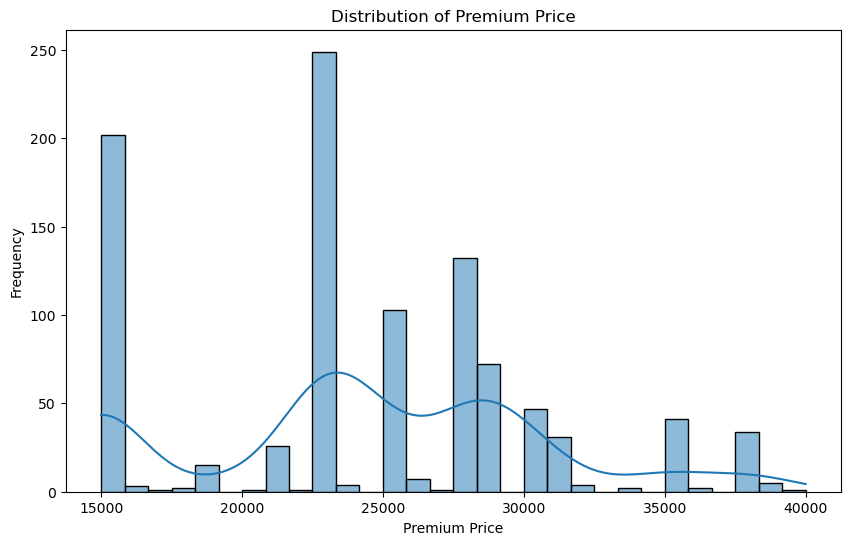

In [12]:
plt.figure(figsize=(10, 6))
sns.histplot(data['PremiumPrice'], kde=True, bins=30)
plt.title('Distribution of Premium Price')
plt.xlabel('Premium Price')
plt.ylabel('Frequency')
plt.show()

Inference from the Histogram:
1. Ih has multiple peaks, so data is not normal.
2. customers are likely falling into a few pricing categories instead of each premium being independently spread out.

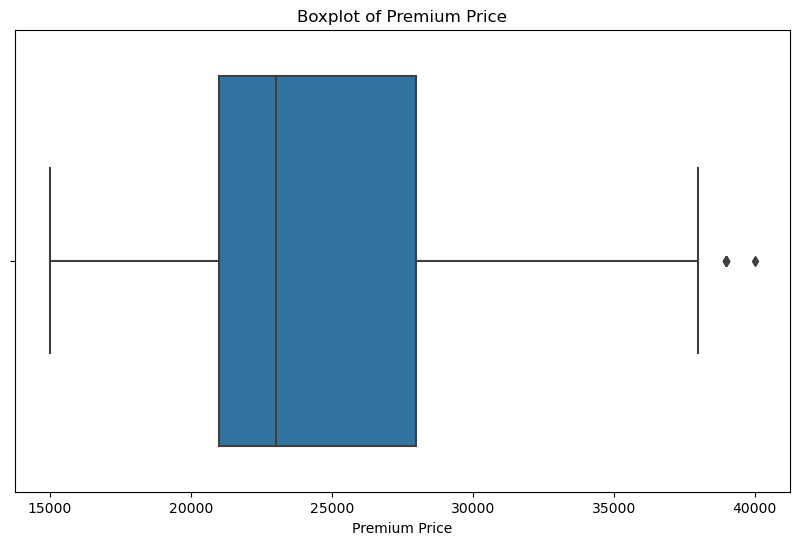

In [13]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=data['PremiumPrice'])
plt.title('Boxplot of Premium Price')
plt.xlabel('Premium Price')
plt.show()

Inference from the Boxplot:
1. The median looks to be around 23k to 24k.
2. The middle 50% of premiums appears to lie roughly between 21k and 28k.
3. There are a couple of high-end outliers near 39k to 40k.

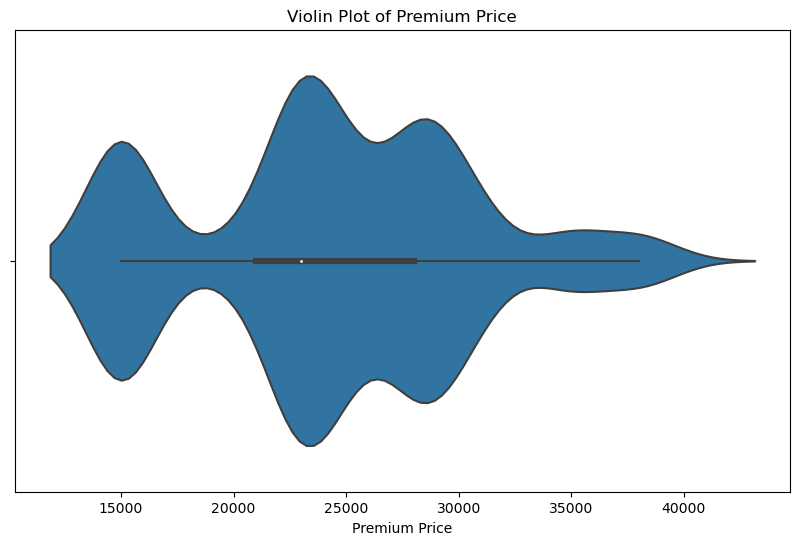

In [14]:
plt.figure(figsize=(10, 6))
sns.violinplot(x=data['PremiumPrice'])
plt.title('Violin Plot of Premium Price')
plt.xlabel('Premium Price')
plt.show()

Inference from the Violinplot:
1. This confirms what the histogram suggested: the variable has multiple dense regions instead of one central mass.
2. The wider parts of the violin show where many observations are concentrated, and those bulges appear in multiple zones.
3. Premium price is likely influenced by segmentation variables such as 'Diabetes', 'BloodPressureProblems', 'AnyTransplants',
       'AnyChronicDiseases', 'KnownAllergies', 'HistoryOfCancerInFamily'.

# Distribution Analysis For Age, Height, Weight and NumberOfMarSurgeries

In [15]:
rest_cols = [col for col in data.columns if col not in bin_cols + ['PremiumPrice']]
rest_cols

['Age', 'Height', 'Weight', 'NumberOfMajorSurgeries']

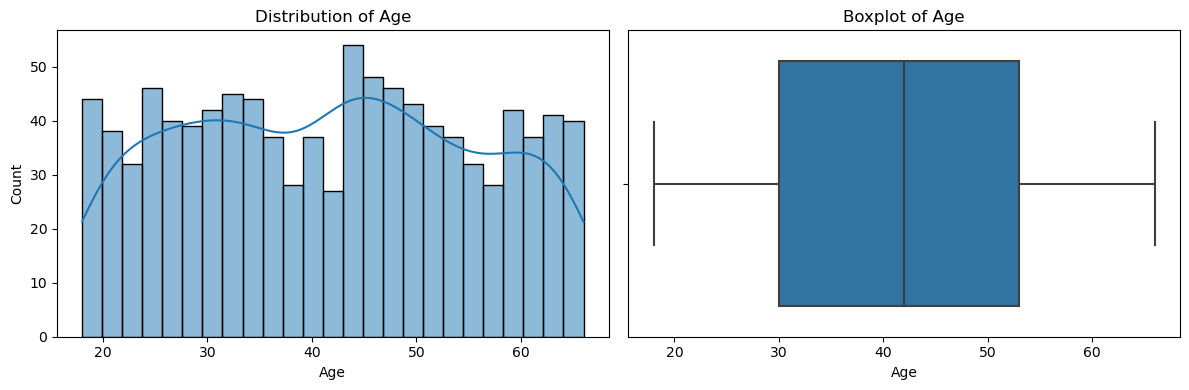

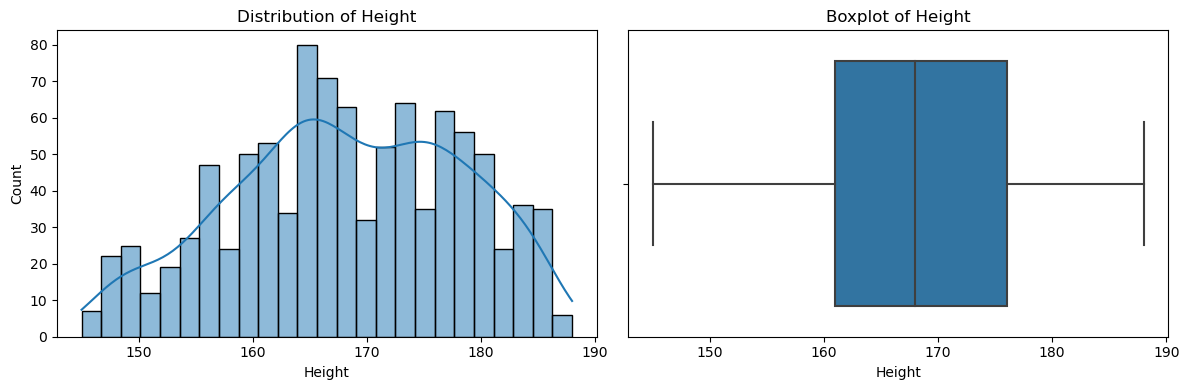

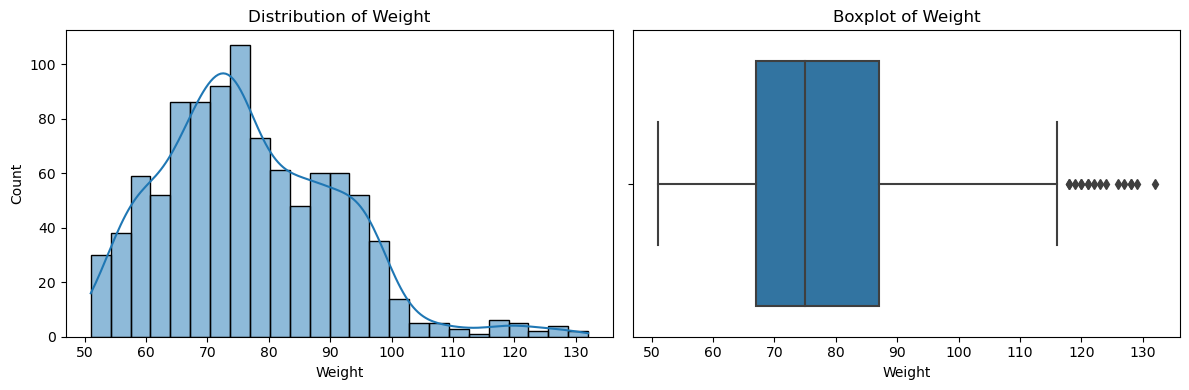

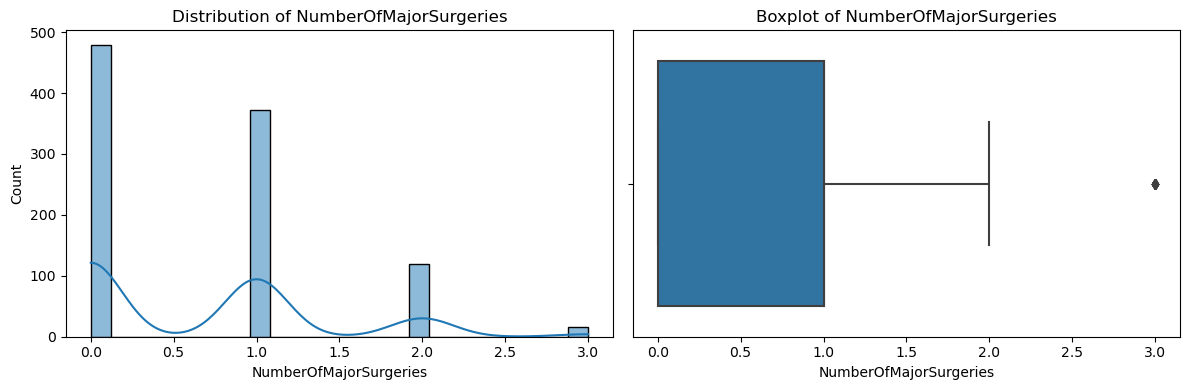

In [16]:
for col in rest_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    sns.histplot(data[col], kde=True, bins=25, ax=axes[0])
    axes[0].set_title(f"Distribution of {col}")

    sns.boxplot(x=data[col], ax=axes[1])
    axes[1].set_title(f"Boxplot of {col}")

    plt.tight_layout()
    plt.show()

Inference from the Age plots:
1. Age is spread across the range from 18 to 66.
2. Most individuals are concentrated around the middle age groups.
3. The boxplot does not show any strong outliers, so Age looks well balanced.

Inference from the Height plots:
1. Height looks close to a normal distribution.
2. Most individuals are concentrated around the mid-range height values.
3. There are no major outliers in Height, so this feature looks stable.

Inference from the Weight plots:
1. Weight is slightly right-skewed.
2. Most individuals lie in the lower to middle weight range.
3. The boxplot shows some high-end outliers, which means a few individuals have unusually high weight.

Inference from the NumberOfMajorSurgeries plots:
1. NumberOfMajorSurgeries is highly right-skewed.
2. Most individuals have 0 or 1 major surgery.
3. Very few individuals have 2 or 3 major surgeries, so this feature is imbalanced.

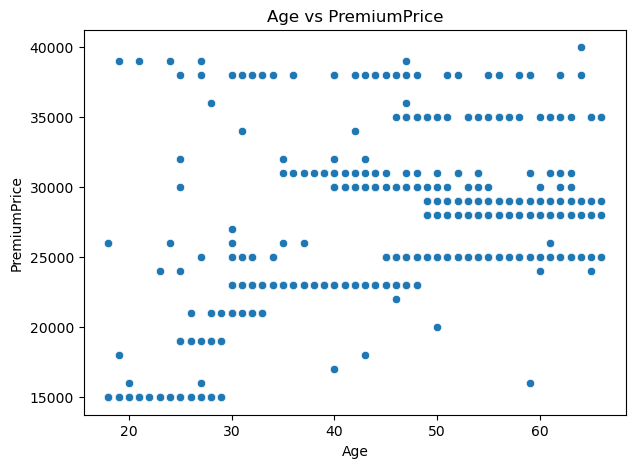

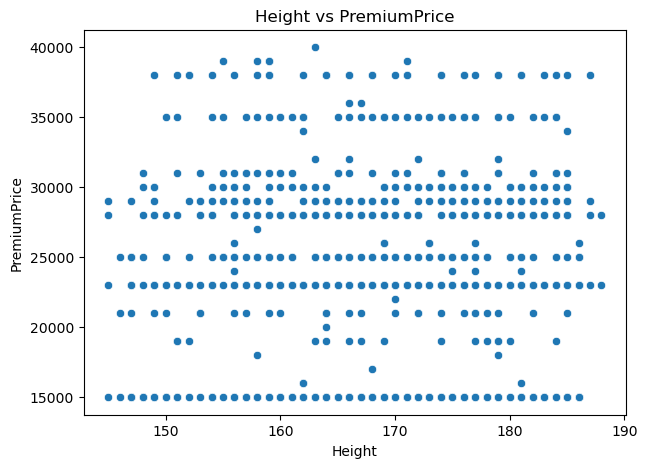

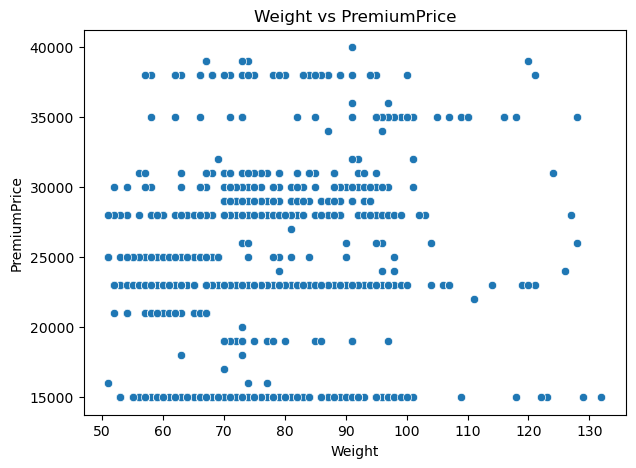

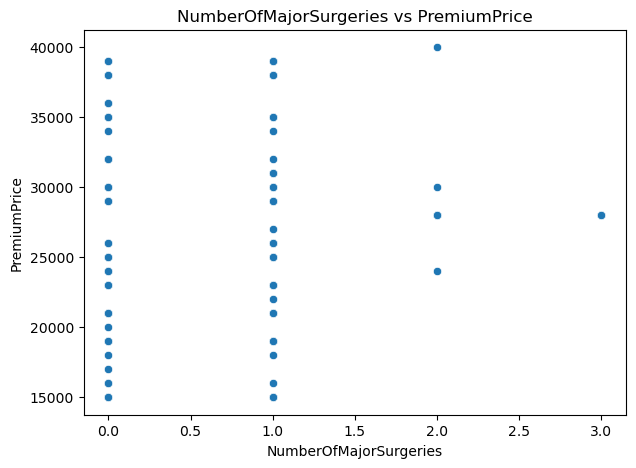

In [17]:
for col in rest_cols:
    plt.figure(figsize=(7, 5))
    sns.scatterplot(data=data, x=col, y='PremiumPrice')
    plt.title(f"{col} vs PremiumPrice")
    plt.show()

Inference from Age vs PremiumPrice:
1. Age shows a mild positive relationship with PremiumPrice.
2. Higher age groups generally appear to have higher premium values.
3. The relationship is not perfectly linear because PremiumPrice is spread across multiple pricing bands.

Inference from Height vs PremiumPrice:
1. Height does not show any strong relationship with PremiumPrice.
2. The points are widely scattered across all premium ranges.
3. This suggests that Height alone may not be an important factor in deciding PremiumPrice.

Inference from Weight vs PremiumPrice:
1. Weight shows a slight positive association with PremiumPrice.
2. Some higher weight values are linked with higher premium ranges.
3. However, the scatter is still broad, so Weight alone is not a strong predictor of PremiumPrice.


Inference from NumberOfMajorSurgeries vs PremiumPrice:
1. NumberOfMajorSurgeries shows a clearer relationship with PremiumPrice.
2. Individuals with more surgeries tend to appear more often in the higher premium ranges.
3. This suggests that medical history has a stronger influence on premium pricing.

# Extra Visualizations Tableau May Not Have Covered

## Pairplot for key numeric field

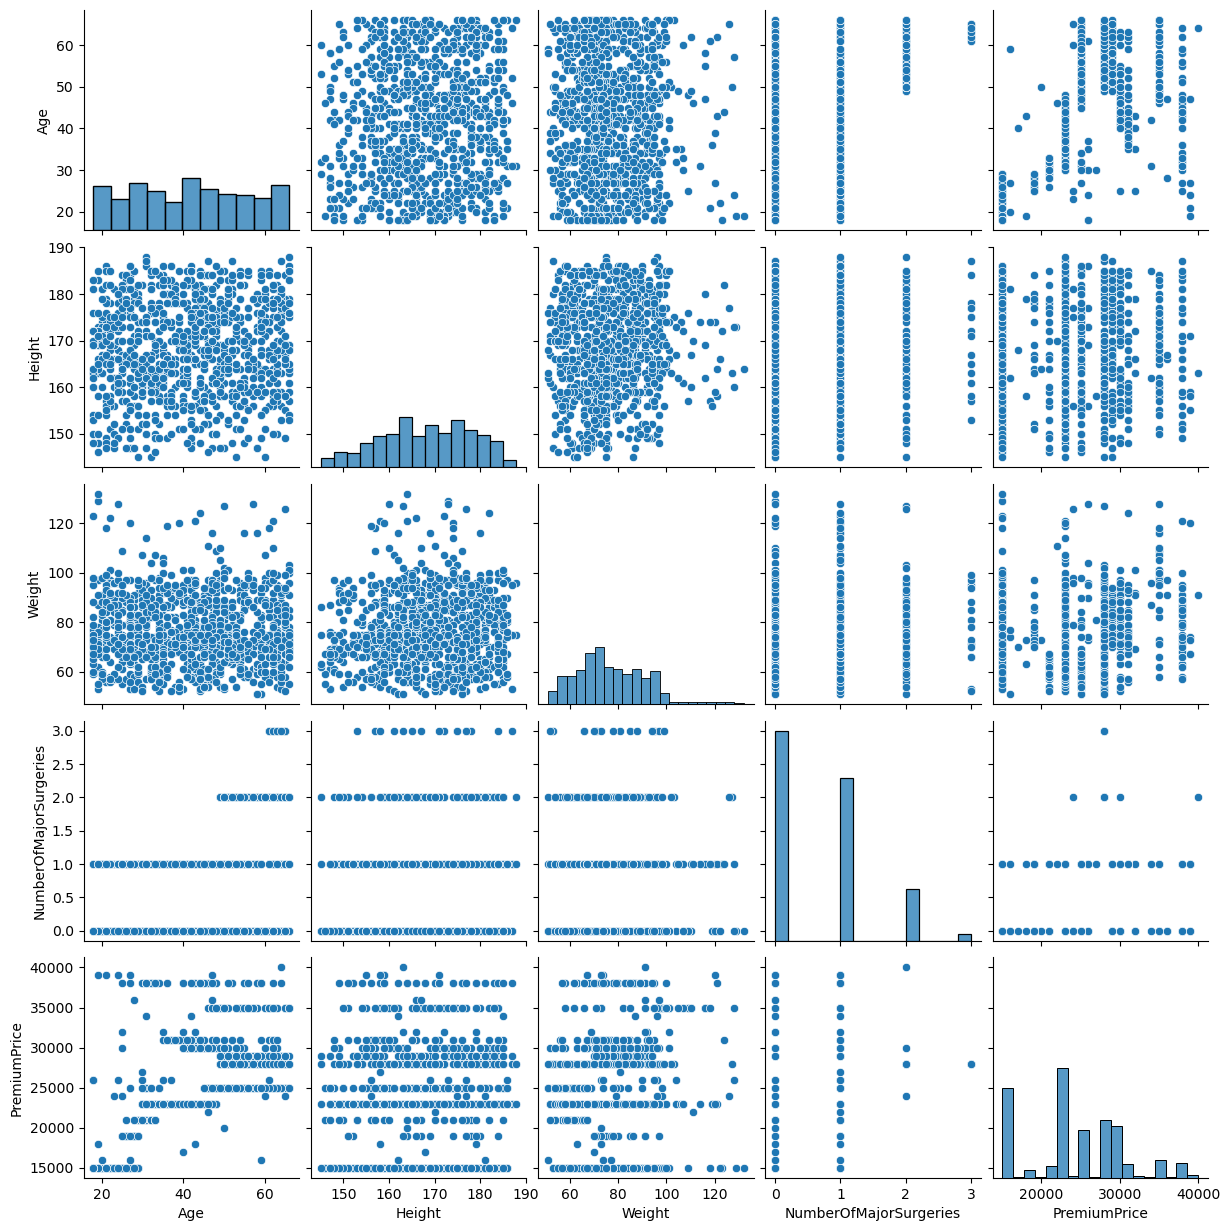

In [18]:
sns.pairplot(data[rest_cols + ['PremiumPrice']])
plt.show()

Inference from the Pairplot:
1. Height and Weight show a mild positive relationship.
2. Age does not show a strong relationship with Height or Weight.
3. NumberOfMajorSurgeries is highly imbalanced, with most individuals having 0 or 1 surgery.
4. PremiumPrice appears in fixed horizontal bands, which indicates slab-based pricing.
5. Age and NumberOfMajorSurgeries show a more noticeable relationship with PremiumPrice.
6. Height has very little visible influence on PremiumPrice, while Weight has only a slight effect.

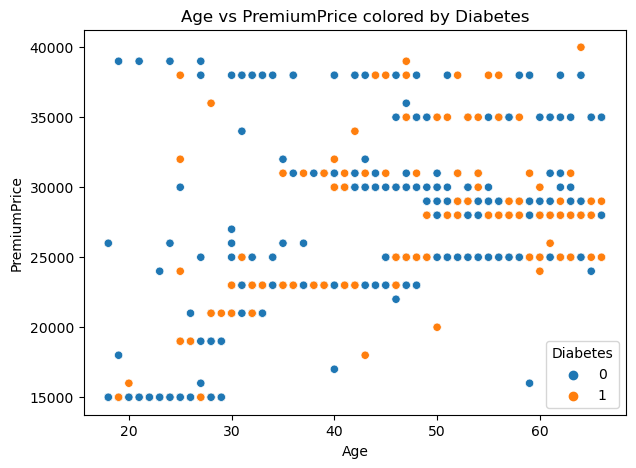

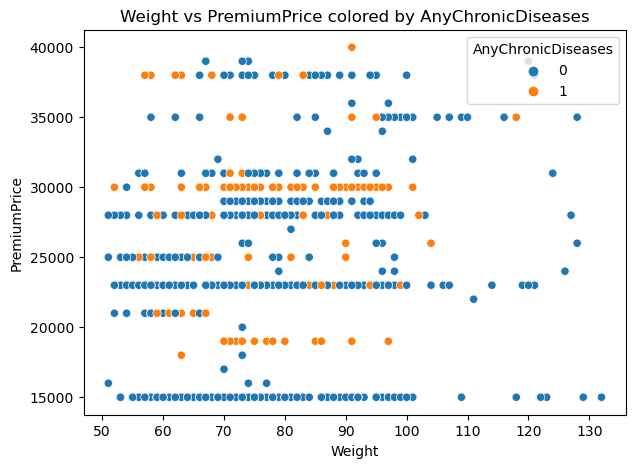

In [19]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=data, x="Age", y="PremiumPrice", hue="Diabetes")
plt.title("Age vs PremiumPrice colored by Diabetes")
plt.show()

plt.figure(figsize=(7, 5))
sns.scatterplot(data=data, x="Weight", y="PremiumPrice", hue="AnyChronicDiseases")
plt.title("Weight vs PremiumPrice colored by AnyChronicDiseases")
plt.show()

Inference from the colored scatter plot:
1. As the age increases patients with diabetes increasing and so the premium price.
2. Wight vs PremiumPrice colored by AnyChronicDiseases doesn't show strong coupling.

## Correlation Analysis

In [20]:
corr_matrix = data[data.columns].corr(method="pearson")
corr_matrix

,Age,Diabetes,BloodPressureProblems,AnyTransplants,AnyChronicDiseases,Height,Weight,KnownAllergies,HistoryOfCancerInFamily,NumberOfMajorSurgeries,PremiumPrice
Age,1.000000,0.210908,0.244888,-0.008549,0.051072,0.039879,-0.018590,-0.024416,-0.027623,0.429181,0.697540
Diabetes,0.210908,1.000000,0.127727,-0.036652,-0.089428,-0.003783,-0.024563,-0.080102,-0.055527,0.122722,0.076209
BloodPressureProblems,0.244888,0.127727,1.000000,-0.024538,0.045424,-0.037926,-0.061016,-0.011550,0.048239,0.251568,0.167097
AnyTransplants,-0.008549,-0.036652,-0.024538,1.000000,0.035285,-0.031543,0.002087,0.001876,-0.020171,-0.004154,0.289056
AnyChronicDiseases,0.051072,-0.089428,0.045424,0.035285,1.000000,0.047419,-0.033318,-0.027418,0.008666,0.014835,0.208610
Height,0.039879,-0.003783,-0.037926,-0.031543,0.047419,1.000000,0.066946,-0.010200,0.010549,0.037289,0.026910
Weight,-0.018590,-0.024563,-0.061016,0.002087,-0.033318,0.066946,1.000000,0.037492,0.003481,-0.006108,0.141507
KnownAllergies,-0.024416,-0.080102,-0.011550,0.001876,-0.027418,-0.010200,0.037492,1.000000,0.115383,0.103923,0.012103
HistoryOfCancerInFamily,-0.027623,-0.055527,0.048239,-0.020171,0.008666,0.010549,0.003481,0.115383,1.000000,0.212657,0.083139
NumberOfMajorSurgeries,0.429181,0.122722,0.251568,-0.004154,0.014835,0.037289,-0.006108,0.103923,0.212657,1.000000,0.264250


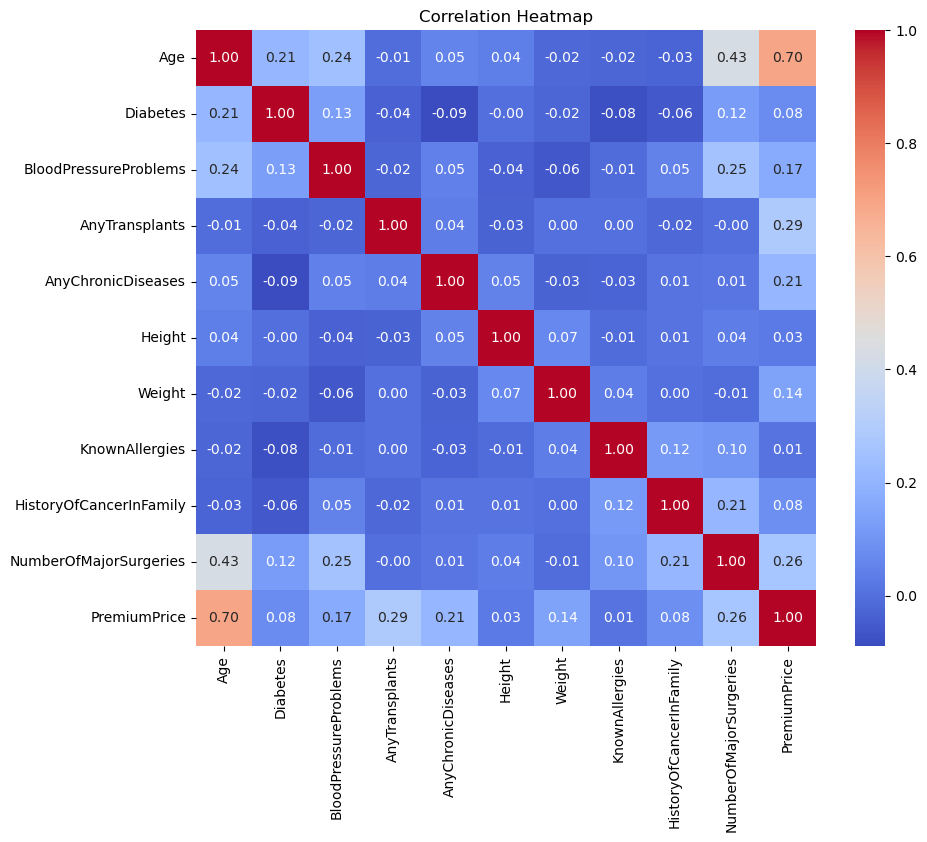

In [21]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

Inference from the Correlation Heatmap:
1. Age has the strongest positive correlation with PremiumPrice at 0.70, which means age is the most influential feature among all variables in deciding the premium.
2. AnyTransplants also shows a noticeable positive correlation with PremiumPrice at 0.29, which suggests that people with transplant history tend to have higher premium prices.
3. NumberOfMajorSurgeries has a positive correlation of 0.26 with PremiumPrice, so medical history also plays an important role in premium calculation.
4. AnyChronicDiseases has a positive correlation of 0.21 with PremiumPrice, which means chronic disease status also increases premium to some extent.
5. BloodPressureProblems and Weight have weak positive correlations with PremiumPrice at 0.17 and 0.14 respectively, so their impact is present but not very strong.
6. Height and KnownAllergies have almost zero correlation with PremiumPrice, which means they have very little linear relationship with the target variable.
7. Among the feature-to-feature relationships, Age and NumberOfMajorSurgeries have a moderate positive correlation of 0.43, which suggests that higher age may be associated with more surgeries.
8. Age also has small positive correlations with Diabetes and BloodPressureProblems, which is reasonable because these conditions may become more common with increasing age.
9. Most correlations between features are low, so there is no strong multicollinearity problem in the dataset.
10. Overall, Age is the most important numeric driver of PremiumPrice, while transplant history, surgeries and chronic diseases also contribute to higher premiums.

In [22]:
spearman_corr = data[rest_cols + ['PremiumPrice']].corr(method="spearman")
print(spearman_corr['PremiumPrice'].sort_values(ascending=False))

PremiumPrice              1.000000
Age                       0.739088
NumberOfMajorSurgeries    0.289482
Weight                    0.129324
Height                    0.023128
Name: PremiumPrice, dtype: float64


Inference from the Spearman Correlation:
1. Age has the highest Spearman correlation with PremiumPrice, so it has the strongest monotonic effect on premium.
2. NumberOfMajorSurgeries comes next, which shows that medical history is also an important factor in premium pricing.
3. Weight has only a weak positive correlation with PremiumPrice.
4. Height has almost no correlation with PremiumPrice.
5. The Spearman results are consistent with the scatter plots, pairplot and Pearson heatmap.
6. This means the ranking of premium is influenced more by Age and surgeries than by Height or Weight.

# Outlier Detection With IQR

In [23]:
def iqr_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    return {
        "column": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "LowerBound": lower_bound,
        "UpperBound": upper_bound,
        "OutlierCount": len(outliers),
        "OutlierPercent": round(len(outliers) / len(df) * 100, 2)
    }

In [24]:
outlier_results = pd.DataFrame([iqr_outliers(data, col) for col in data.columns])
outlier_results

,column,Q1,Q3,IQR,LowerBound,UpperBound,OutlierCount,OutlierPercent
0,Age,30.0,53.0,23.0,-4.5,87.5,0,0.00
1,Diabetes,0.0,1.0,1.0,-1.5,2.5,0,0.00
2,BloodPressureProblems,0.0,1.0,1.0,-1.5,2.5,0,0.00
3,AnyTransplants,0.0,0.0,0.0,0.0,0.0,55,5.58
4,AnyChronicDiseases,0.0,0.0,0.0,0.0,0.0,178,18.05
5,Height,161.0,176.0,15.0,138.5,198.5,0,0.00
6,Weight,67.0,87.0,20.0,37.0,117.0,16,1.62
7,KnownAllergies,0.0,0.0,0.0,0.0,0.0,212,21.50
8,HistoryOfCancerInFamily,0.0,0.0,0.0,0.0,0.0,116,11.76
9,NumberOfMajorSurgeries,0.0,1.0,1.0,-1.5,2.5,16,1.62


In [25]:
col = "PremiumPrice"

q1 = data[col].quantile(0.25)
q3 = data[col].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

df_no_outliers = data[(data[col] >= lower) & (data[col] <= upper)]

print("Original mean:", data[col].mean())
print("Without outliers mean:", df_no_outliers[col].mean())
print("Original median:", data[col].median())
print("Without outliers median:", df_no_outliers[col].median())

Original mean: 24336.713995943206
Without outliers mean: 24245.918367346938
Original median: 23000.0
Without outliers median: 23000.0


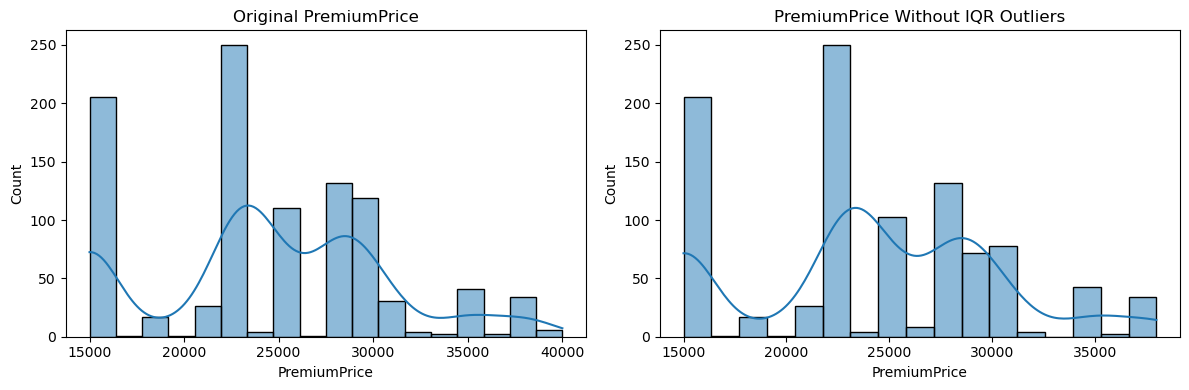

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(data=data, x=col, kde=True, ax=axes[0])
axes[0].set_title("Original PremiumPrice")

sns.histplot(data=df_no_outliers, x=col, kde=True, ax=axes[1])
axes[1].set_title("PremiumPrice Without IQR Outliers")

plt.tight_layout()
plt.show()

Inference from Outlier Analysis:
1. The distribution of PremiumPrice before and after IQR-based outlier removal looks very similar.
2. This means the outliers are not heavily affecting the overall shape of the data.
3. The central premium bands are still clearly visible even after removing the outliers.
4. The mean may change slightly after outlier removal, but the median and the overall distribution do not change much.
5. This suggests that the detected outliers are few in number and do not strongly distort the dataset.
6. Since PremiumPrice is the target variable, removing these outliers may lead to loss of valid high-premium cases.
7. Therefore, outlier removal may not be necessary in this case unless those values are confirmed to be incorrect entries.
8. A better option may be to keep the data as it is and use robust models.

# Hypothesis Testing: T-Tests For Binary Flags

--> A t-test is only for comparing two groups, so we will use it for the features which have binary(0 or 1) categories.

In [27]:
for col in bin_cols:
    group0 = data[data[col] == 0]['PremiumPrice']
    group1 = data[data[col] == 1]['PremiumPrice']

    t_stat, p_value = ttest_ind(group0, group1, equal_var=False)

    print(f"\nT-test for {col} vs PremiumPrice:")
    print("Mean Premium for 0:", group0.mean())
    print("Mean Premium for 1:", group1.mean())
    print("t-statistic:", t_stat)
    print("p-value:", p_value)
    if p_value < 0.05:
        print("Result: Statistically significant difference in PremiumPrice between groups.")
    else:
        print("Result: No statistically significant difference in PremiumPrice between groups.")


T-test for Diabetes vs PremiumPrice:
Mean Premium for 0: 23931.81818181818
Mean Premium for 1: 24896.135265700483
t-statistic: -2.4489285982890396
p-value: 0.014508142994631809
Result: Statistically significant difference in PremiumPrice between groups.

T-test for BloodPressureProblems vs PremiumPrice:
Mean Premium for 0: 23356.870229007633
Mean Premium for 1: 25448.051948051947
t-statistic: -5.370281271166068
p-value: 9.813498313247295e-08
Result: Statistically significant difference in PremiumPrice between groups.

T-test for AnyTransplants vs PremiumPrice:
Mean Premium for 0: 23897.95918367347
Mean Premium for 1: 31763.636363636364
t-statistic: -6.2599390386040215
p-value: 5.544902737541748e-08
Result: Statistically significant difference in PremiumPrice between groups.

T-test for AnyChronicDiseases vs PremiumPrice:
Mean Premium for 0: 23725.247524752474
Mean Premium for 1: 27112.3595505618
t-statistic: -7.707663368460665
p-value: 1.7279736467737666e-13
Result: Statistically sign

Inference from the T-test:
1. The t-test compares the mean PremiumPrice for people with and without each binary medical condition.
2. For the columns where the p-value is less than 0.05, the difference in mean PremiumPrice is statistically significant.
3. This means those medical conditions have a meaningful effect on premium pricing.
4. If the mean premium for group 1 is higher than group 0, then the presence of that condition is associated with higher premium.
5. If the p-value is greater than 0.05, then the condition does not show a statistically significant difference in premium.
6. From the earlier correlation analysis, conditions such as AnyTransplants, AnyChronicDiseases and BloodPressureProblems are expected to have stronger impact on PremiumPrice.
7. Conditions with very weak correlation, such as KnownAllergies, may not show significant difference in the t-test.
8. Overall, the t-test helps confirm which binary medical flags truly affect PremiumPrice at the group level.

# Hypothesis Testing: ANOVA For Surgery Groups

ANOVA should be used to compare the mean of a numeric target across three or more groups. So we will use it for only one column "NumberofMarSurgeries"

In [28]:
print(data["NumberOfMajorSurgeries"].value_counts().sort_index())

0    479
1    372
2    119
3     16
Name: NumberOfMajorSurgeries, dtype: int64


We can clearly see that it has 4 categories only so we will use ANOVA for this column only.

In [29]:
groups = [group['PremiumPrice'] for name, group in data.groupby('NumberOfMajorSurgeries')]
f_stat, p_value = stats.f_oneway(*groups)

print(f"\nANOVA test for NumberOfMajorSurgeries vs PremiumPrice:")
print("F-statistic:", f_stat)
print("p-value:", p_value)
if p_value < 0.05:
    print("Result: Statistically significant difference in PremiumPrice across NumberOfMajorSurgeries groups.")
else:
    print("Result: No statistically significant difference in PremiumPrice across NumberOfMajorSurgeries groups.")


ANOVA test for NumberOfMajorSurgeries vs PremiumPrice:
F-statistic: 26.13539359740762
p-value: 2.8711631377228097e-16
Result: Statistically significant difference in PremiumPrice across NumberOfMajorSurgeries groups.


Inference:

Therefore we can conclude that, Premium price changes significantly depending on how many major surgeries a person has.

# Hypothesis Testing: Chi-Square Between Two Categorical Variables

In [30]:
from itertools import combinations
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm

binary_combinations = list(combinations(bin_cols, 2))

for col1, col2 in binary_combinations:
    model = smf.ols(f"PremiumPrice ~ C({col1}) * C({col2})", data=data).fit()
    anova_result = anova_lm(model, typ=2)

    print(f"\nInteraction effect for {col1} and {col2} on PremiumPrice:")
    print(anova_result)

    interaction_row = f"C({col1}):C({col2})"
    p_value = anova_result.loc[interaction_row, "PR(>F)"]

    if p_value < 0.05:
        print("Result: Statistically significant interaction effect on PremiumPrice.")
    else:
        print("Result: No statistically significant interaction effect on PremiumPrice.")


Interaction effect for Diabetes and BloodPressureProblems on PremiumPrice:
                                            sum_sq     df          F  \
C(Diabetes)                           1.176800e+08    1.0   3.130064   
C(BloodPressureProblems)              9.680363e+08    1.0  25.747914   
C(Diabetes):C(BloodPressureProblems)  3.428923e+08    1.0   9.120281   
Residual                              3.691995e+10  982.0        NaN   

                                            PR(>F)  
C(Diabetes)                           7.717105e-02  
C(BloodPressureProblems)              4.651368e-07  
C(Diabetes):C(BloodPressureProblems)  2.593301e-03  
Residual                                       NaN  
Result: Statistically significant interaction effect on PremiumPrice.

Interaction effect for Diabetes and AnyTransplants on PremiumPrice:
                                     sum_sq     df          F        PR(>F)
C(Diabetes)                    2.901377e+08    1.0   8.217030  4.238560e-03
C(AnyTr

# Regression Analysis For Hypothesis Testing

In [31]:
for col in data.columns:
    formula = f"{'PremiumPrice'} ~ {col}"
    model = smf.ols(formula, data=data).fit()

    print(f"\nRegression: {'PremiumPrice'} ~ {col}")
    print(model.summary())


Regression: PremiumPrice ~ Age
                            OLS Regression Results                            
Dep. Variable:           PremiumPrice   R-squared:                       0.487
Model:                            OLS   Adj. R-squared:                  0.486
Method:                 Least Squares   F-statistic:                     932.5
Date:                Sun, 26 Apr 2026   Prob (F-statistic):          1.32e-144
Time:                        11:46:20   Log-Likelihood:                -9687.6
No. Observations:                 986   AIC:                         1.938e+04
Df Residuals:                     984   BIC:                         1.939e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   1.131e+0

Inference from the Regression Analysis:
1. Age is the strongest predictor of PremiumPrice.
2. NumberOfMajorSurgeries and some medical history variables also show noticeable effect on premium.
3. Height has very little effect, while Weight has only a small effect.
4. Overall, premium price is influenced more by age and health conditions than by physical measurements.

# Final Interpretation

In [32]:
final_interpretation = [
    "1. PremiumPrice is not normally distributed and appears in multiple price bands, which suggests slab-based pricing.",
    "2. Age is the strongest factor affecting PremiumPrice, and premium generally increases as age increases.",
    "3. Medical history variables such as NumberOfMajorSurgeries, AnyTransplants, AnyChronicDiseases and BloodPressureProblems also have noticeable influence on premium.",
    "4. Height has very little effect on PremiumPrice, while Weight shows only a small positive effect.",
    "5. The statistical tests confirm that some health-related conditions create significant differences in premium values.",
    "6. Outlier removal is not very useful in this dataset because the overall PremiumPrice distribution remains almost the same after removing outliers.",
    "7. Overall, PremiumPrice is influenced more by age and health conditions than by physical measurements.",
    "8. This suggests that insurance premium calculation in this dataset is mainly driven by health risk-related medical and age factors."
]

print("Final Interpretation:")
for point in final_interpretation:
    print(point)

Final Interpretation:
1. PremiumPrice is not normally distributed and appears in multiple price bands, which suggests slab-based pricing.
2. Age is the strongest factor affecting PremiumPrice, and premium generally increases as age increases.
3. Medical history variables such as NumberOfMajorSurgeries, AnyTransplants, AnyChronicDiseases and BloodPressureProblems also have noticeable influence on premium.
4. Height has very little effect on PremiumPrice, while Weight shows only a small positive effect.
5. The statistical tests confirm that some health-related conditions create significant differences in premium values.
6. Outlier removal is not very useful in this dataset because the overall PremiumPrice distribution remains almost the same after removing outliers.
7. Overall, PremiumPrice is influenced more by age and health conditions than by physical measurements.
8. This suggests that insurance premium calculation in this dataset is mainly driven by health risk-related medical and a

# Feature Engineering

In [33]:
data['Height'].head()

0    155
1    180
2    158
3    183
4    166
Name: Height, dtype: int64

Creating BMI feature using the Weight and Height.

In [34]:
data_model = data.copy()

data_model["Height_m"] = data_model["Height"] / 100
data_model["BMI"] = data_model["Weight"] / (data_model["Height_m"] ** 2)

# Data Preparation

In [35]:
features = bin_cols + rest_cols + ["Height_m", "BMI"]
label = "PremiumPrice"

In [36]:
X = data_model[features]
y = data_model[label]

X.head()

,Diabetes,BloodPressureProblems,AnyTransplants,AnyChronicDiseases,KnownAllergies,HistoryOfCancerInFamily,Age,Height,Weight,NumberOfMajorSurgeries,Height_m,BMI
0,0,0,0,0,0,0,45,155,57,0,1.55,23.725286
1,1,0,0,0,0,0,60,180,73,0,1.80,22.530864
2,1,1,0,0,0,0,36,158,59,1,1.58,23.634033
3,1,1,0,1,0,0,52,183,93,2,1.83,27.770313
4,0,0,0,1,0,0,38,166,88,1,1.66,31.934969


In [37]:
y.head()

0    25000
1    29000
2    23000
3    28000
4    23000
Name: PremiumPrice, dtype: int64

In [38]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (788, 12)
X_test shape: (198, 12)
y_train shape: (788,)
y_test shape: (198,)


# Preprocessing Pipeline

Need of pipeline:

--> For linear models, scaling helps.

--> For tree-based models, scaling is usually not necessary, but using a general preprocessing setup is still clean.

In [39]:
linear_numeric_cols = rest_cols+["BMI"]
linear_binary_cols = bin_cols

linear_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            linear_numeric_cols
        ),
        (
            "bin",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent"))
            ]),
            linear_binary_cols
        )
    ]
)

In [40]:
tree_numeric_cols = rest_cols+["BMI"]
tree_binary_cols = bin_cols

tree_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median"))
            ]),
            tree_numeric_cols
        ),
        (
            "bin",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent"))
            ]),
            tree_binary_cols
        )
    ]
)

# Building Baseline and Candidate Models

In [41]:
models = {
    "LinearRegression": Pipeline([
        ("preprocessor", linear_preprocessor),
        ("model", LinearRegression())
    ]),

    "Ridge": Pipeline([
        ("preprocessor", linear_preprocessor),
        ("model", Ridge(alpha=1.0))
    ]),

    "DecisionTree": Pipeline([
        ("preprocessor", tree_preprocessor),
        ("model", DecisionTreeRegressor(max_depth=4, random_state=42))
    ]),

    "RandomForest": Pipeline([
        ("preprocessor", tree_preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=300,
            max_depth=6,
            min_samples_split=10,
            min_samples_leaf=5,
            random_state=42
        ))
    ]),

    "GradientBoosting": Pipeline([
        ("preprocessor", tree_preprocessor),
        ("model", GradientBoostingRegressor(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        ))
    ])
}

# Model Comparison

In [42]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "mae": "neg_mean_absolute_error",
    "mse": "neg_mean_squared_error",
    "rmse": "neg_root_mean_squared_error",
    "r2": "r2"
}

cv_results = []

for name, pipeline in models.items():
    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        return_train_score=False
    )

    cv_results.append({
    "Model": name,
    "CV_MAE": -scores["test_mae"].mean(),
    "CV_MSE": -scores["test_mse"].mean(),
    "CV_RMSE": -scores["test_rmse"].mean(),
    "CV_R2": scores["test_r2"].mean()
})

cv_results_df = pd.DataFrame(cv_results).sort_values(by="CV_RMSE")
cv_results_df

c:\Users\aakas\anaconda3\lib\site-packages\sklearn\impute\_base.py:49: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode = stats.mode(array)
c:\Users\aakas\anaconda3\lib\site-packages\sklearn\impute\_base.py:49: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode 

,Model,CV_MAE,CV_MSE,CV_RMSE,CV_R2
3,RandomForest,1508.009695,9.517799e+06,3054.388499,0.745250
4,GradientBoosting,1761.054835,1.028221e+07,3150.989746,0.726442
2,DecisionTree,1948.170171,1.314454e+07,3616.855762,0.652056
1,Ridge,2761.579882,1.501461e+07,3860.183004,0.600555
0,LinearRegression,2763.670379,1.504636e+07,3864.021598,0.599688


CV--> Cross Validation

1. Lower CV_MAE is better
2. Lower CV_RMSE is better
3. Higher CV_R2 is better

Inference from Model Comparison:

1. RandomForest is the best performing model among all the tested models.
2. It has the lowest CV_MAE and CV_RMSE, which means it gives the smallest prediction errors.
3. It also has the highest CV_R2, which means it explains the target variable better than the other models.
4. GradientBoosting performs well, but it is slightly weaker than RandomForest on all key metrics.
5. LinearRegression and Ridge perform the worst, which suggests that the relationship between features and PremiumPrice is not purely linear.
6. Overall, tree-based ensemble models are better suited for this dataset, and RandomForest is the final best model.

# Fitting and testing the best model on the test data

In [43]:
best_model = models["RandomForest"]
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

test_mae = mean_absolute_error(y_test, y_pred)
test_rmse = mean_squared_error(y_test, y_pred, squared=False)
test_r2 = r2_score(y_test, y_pred)

print("Test MAE:", test_mae)
print("Test RMSE:", test_rmse)
print("Test R2:", test_r2)

c:\Users\aakas\anaconda3\lib\site-packages\sklearn\impute\_base.py:49: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode = stats.mode(array)


Test MAE: 1297.7118110079552
Test RMSE: 2239.9605665423246
Test R2: 0.8823383001659253


Inference from train/CV vs test metrics:

1. RandomForest cross-validation values are CV_MAE is 1508, CV_RMSE is 3054, CV_R2 is 0.745, while the held-out test results are Test MAE ia 1298, Test RMSE is 2240, Test R2 is 0.882.
2. The test set gives lower error and higher R² than the CV average, so this particular hold-out split was easier and the model generalizes well on it.
3. The cross-validation metrics remain the more reliable training/generalization benchmark, so the model should be trusted as strong but still validated with more splits if possible.

# Predicted Vs Actual Plot

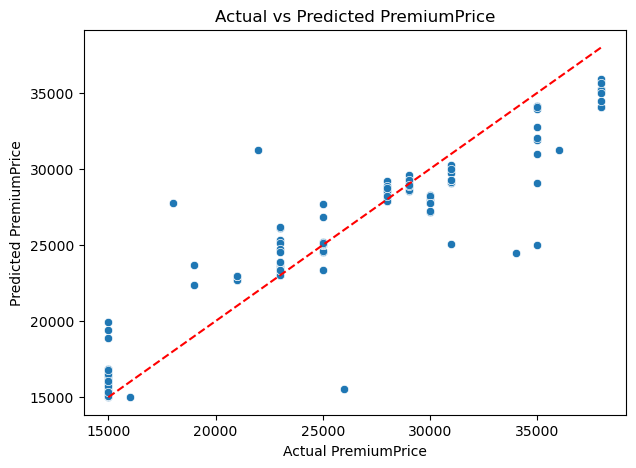

In [44]:
plt.figure(figsize=(7, 5))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red", linestyle="--")
plt.xlabel("Actual PremiumPrice")
plt.ylabel("Predicted PremiumPrice")
plt.title("Actual vs Predicted PremiumPrice")
plt.show()

Inference from the Predicted vs Actual Plot:

1. Most points lie close to the diagonal line, which means the model predictions generally match the actual PremiumPrice values.
2. A few points deviate above and below the line, indicating the model sometimes overestimates or underestimates premiums, especially in the mid-to-high range.
3. Overall, the scatter shows good predictive alignment and suggests the RandomForest model is capturing the underlying premium pattern well.

# Residual Analysis

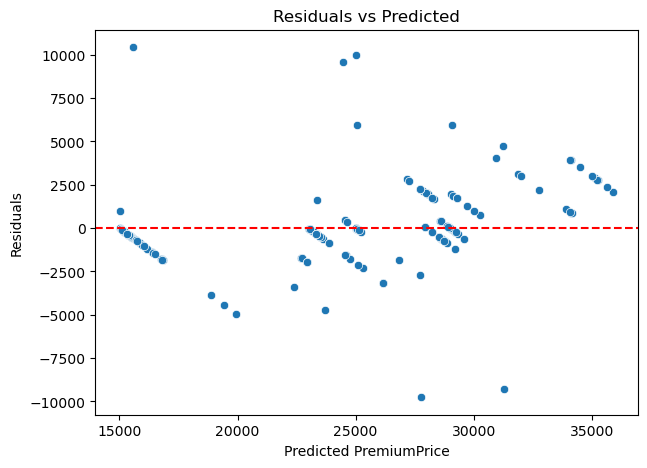

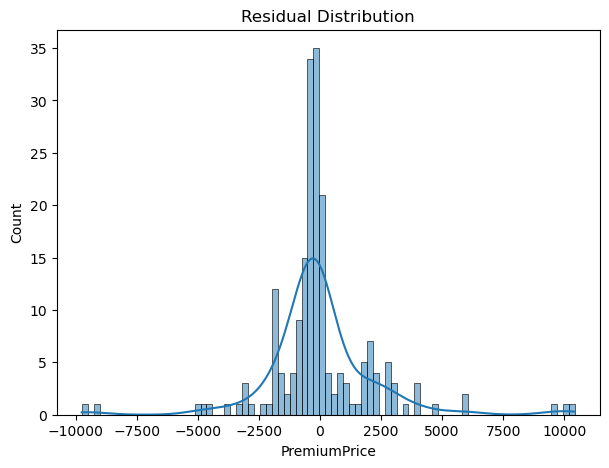

In [45]:
residuals = y_test - y_pred

plt.figure(figsize=(7, 5))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted PremiumPrice")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted")
plt.show()

plt.figure(figsize=(7, 5))
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()

Inference from Residual Analysis:

1. The residual scatter plot shows the errors distributed around the zero line, which means the RandomForest predictions do not show a strong systematic bias across predicted premium values.
2. The residual distribution plot is centered near zero and appears fairly symmetric, indicating that overestimation and underestimation are balanced.
3. Together, these plots suggest the model error is stable and there is no obvious pattern of heteroscedasticity, so the model is reasonably well-behaved on the test set.

# Confidence / Prediction Intervals

## On Training Data

In [46]:
cv_pred = cross_val_predict(best_model, X_train, y_train, cv=cv)
cv_residuals = y_train - cv_pred

lower_q = np.quantile(cv_residuals, 0.025)
upper_q = np.quantile(cv_residuals, 0.975)

print("Residual 2.5% quantile:", lower_q)
print("Residual 97.5% quantile:", upper_q)

c:\Users\aakas\anaconda3\lib\site-packages\sklearn\impute\_base.py:49: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode = stats.mode(array)
c:\Users\aakas\anaconda3\lib\site-packages\sklearn\impute\_base.py:49: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode 

Residual 2.5% quantile: -4884.60692534043
Residual 97.5% quantile: 6643.928783490396


Residuals show that 95% of prediction errors fall between roughly –4885 and +6644, indicating the model’s prediction spread and variability around the true values.

## On Testing Data

In [47]:
pred_interval_lower = y_pred + lower_q
pred_interval_upper = y_pred + upper_q

pred_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred,
    "PI_Lower_95": pred_interval_lower,
    "PI_Upper_95": pred_interval_upper
})

pred_df.head(10)

,Actual,Predicted,PI_Lower_95,PI_Upper_95
0,31000,29049.945213,24165.338288,35693.873996
1,31000,29123.405114,24238.798188,35767.333897
2,29000,29207.781413,24323.174488,35851.710197
3,15000,16810.172142,11925.565217,23454.100926
4,23000,26146.065005,21261.458080,32789.993789
5,29000,28619.119423,23734.512497,35263.048206
6,25000,24536.331006,19651.724081,31180.259790
7,23000,23433.675660,18549.068735,30077.604444
8,28000,28532.048697,23647.441772,35175.977480
9,28000,27915.904799,23031.297873,34559.833582


In simple terms: your table shows that the model’s predictions are close to the actual values, and the true values always fall inside the 95% prediction range. That means the intervals are doing their job — they give a realistic margin of error around each prediction.


# Feature Importance

In [48]:
perm_result = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=20,
    random_state=42,
    scoring="neg_root_mean_squared_error"
)

importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": perm_result.importances_mean
}).sort_values(by="Importance", ascending=False)

importance_df

,Feature,Importance
6,Age,5023.115143
2,AnyTransplants,1507.899256
8,Weight,801.596549
3,AnyChronicDiseases,636.887193
5,HistoryOfCancerInFamily,338.828870
9,NumberOfMajorSurgeries,156.460823
1,BloodPressureProblems,61.850887
11,BMI,7.342798
0,Diabetes,0.371610
10,Height_m,0.000000


Infernece from Feature Importance:

1. Age is by far the most influential factor in predicting outcomes, dominating all other features.
2. Medical history variables like transplants, chronic diseases, and family cancer history also play a strong role.
3. Features such as height, allergies, and diabetes contribute very little or even negatively, meaning they add minimal predictive power to the model.


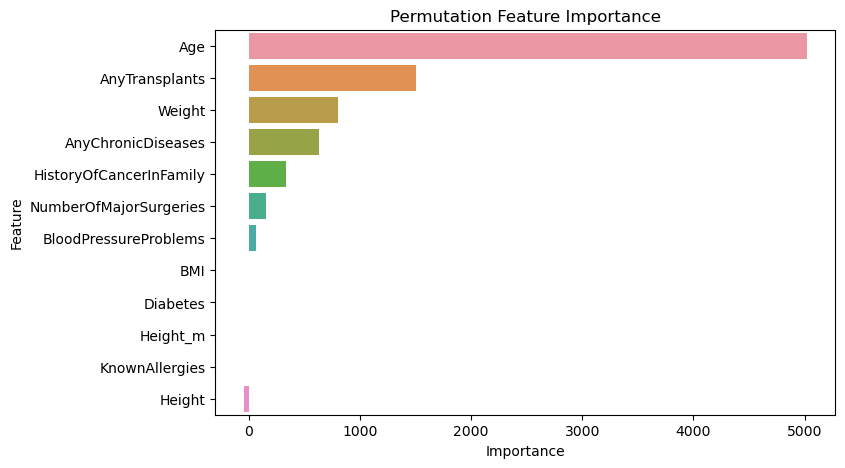

In [49]:
plt.figure(figsize=(8, 5))
sns.barplot(data=importance_df, x="Importance", y="Feature")
plt.title("Permutation Feature Importance")
plt.show()